# Session 8 Step 5: latent-dimension sweep at the best (eta*, lambda*)

Loads `outputs/runs/session8/d_sweep.csv` (produced by
`scripts/session8_d_sweep_analysis.py`). Three runs at d in {8, 16, 32}
share the best (eta*, lambda*) from Step 4. d=32 is the best grid
point already trained as part of Step 4; d=8 and d=16 are the two new
runs from `scripts/launch_session8_step5_dsweep.sh`.

The plan's three plausible outcomes:
- **d small wins** (d=8 best): LeWM intrinsic-dimension mechanism
  is real for this data. Paper recommendation: "use d close to
  estimated intrinsic dimension."
- **d invariant** (all within +/- 0.02): model is robust to d.
- **d large wins** (d=32 best): counterintuitive; the controlled-
  collapse mechanism benefits from latent space to allocate.

In [1]:
from __future__ import annotations
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

REPO = Path.cwd().resolve()
while REPO.name and not (REPO / 'configs' / 'splits').exists():
    REPO = REPO.parent
OUT = REPO / 'outputs' / 'runs' / 'session8'
df = pd.read_csv(OUT / 'd_sweep.csv')
df.round(3)

,d,split,PR_all,PR_within,r2_z_c,r2_CL_future,r2_ct_baseline,delta
0,8,test_a,1.892,3.508,0.435,0.963,0.739,0.224
1,8,test_b,2.215,3.363,0.701,0.810,0.718,0.092
2,8,test_c,3.287,3.587,0.599,0.802,0.350,0.451
3,16,test_a,1.978,4.113,0.418,0.953,0.739,0.214
4,16,test_b,2.365,3.680,0.688,0.821,0.718,0.103
5,16,test_c,3.534,4.040,0.707,0.824,0.350,0.474
6,32,test_a,2.119,4.488,0.545,0.965,0.739,0.227
7,32,test_b,2.607,3.877,0.866,0.878,0.718,0.159
8,32,test_c,3.715,3.816,0.757,0.821,0.350,0.470


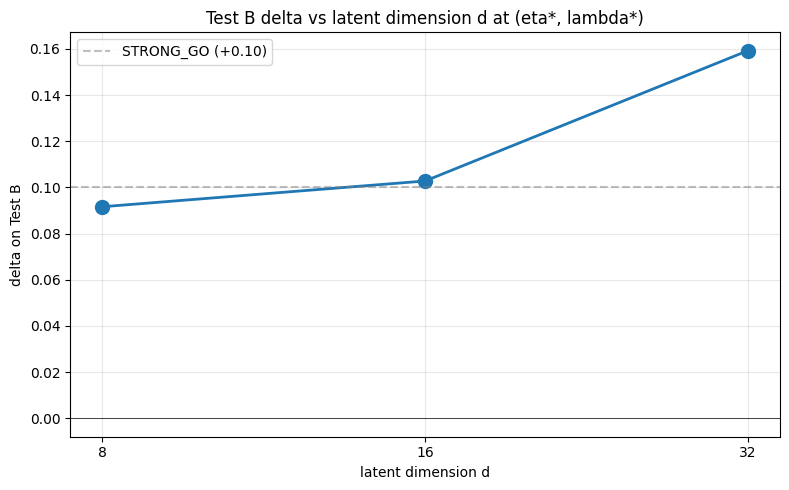

saved fig_d_sweep.png


In [2]:
tb = df[df.split == 'test_b'].sort_values('d')
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(tb['d'], tb['delta'], 'o-', linewidth=2, markersize=10)
ax.axhline(0, color='k', linewidth=0.5)
ax.axhline(0.10, color='gray', linestyle='--', alpha=0.5, label='STRONG_GO (+0.10)')
ax.set_xlabel('latent dimension d')
ax.set_ylabel('delta on Test B')
ax.set_xscale('log', base=2)
ax.set_xticks([8, 16, 32])
ax.set_xticklabels(['8', '16', '32'])
ax.set_title(f'Test B delta vs latent dimension d at (eta*, lambda*)')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / 'fig_d_sweep.png', dpi=130, bbox_inches='tight')
plt.show()
print('saved fig_d_sweep.png')

In [3]:
best_idx = tb['delta'].idxmax()
best_d = int(tb.loc[best_idx, 'd'])
best_delta = float(tb.loc[best_idx, 'delta'])
d_invariant = tb['delta'].max() - tb['delta'].min() <= 0.02
print(f'd values: {list(tb.d)}')
print(f'delta_test_b: {list(tb.delta.round(3))}')
print(f'best d* = {best_d}, delta* = {best_delta:+.3f}')
if d_invariant:
    print('D54 reading: d-invariant. Production d is the smallest tested for compute efficiency.')
elif best_d == 8:
    print('D54 reading: d=8 wins. LeWM intrinsic-dimension mechanism confirmed on physics data.')
elif best_d == 32:
    print('D54 reading: d=32 wins. Counterintuitive; controlled-collapse benefits from larger latent.')
else:
    print('D54 reading: d=16 is the optimum, between the LeWM prediction and the original d=32 default.')

d values: [8, 16, 32]
delta_test_b: [0.092, 0.103, 0.159]
best d* = 32, delta* = +0.159
D54 reading: d=32 wins. Counterintuitive; controlled-collapse benefits from larger latent.
